<a href="https://colab.research.google.com/github/zzhining/test_analysis/blob/main/credit_card_fraud_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 신용카드 사기거래 예측 모델


---


## 프로젝트 목표
---
- 주어진 데이터의 구조를 파악하고, 탐색적 데이터 분석을 수행한다.
- 주어진 데이터를 머신러닝 모델 학습에 적합한 형태로 전처리하여 학습을 수행한다.


## 프로젝트 목차
---

1. **데이터 읽기, 데이터 탐색:** 데이터를 불러오고 Dataframe 구조를 확인

2. **데이터 시각화:** 변수 시각화를 통하여 분포 파악

3. **데이터 전처리:** 머신러닝 모델에 필요한 입력값 형식으로 데이터 처리

4. **머신러닝 모델 수행:** 회귀 모델을 사용하여 학습 수행, 평가 및 예측 수행

## 데이터 출처
---
- [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


## 프로젝트 개요
---

### 📌 배경 (Context)
회사가 신용카드 거래 사기(fraudulent credit card transactions) 를 식별하는 것은 매우 중요합니다.
이러한 기능은 고객이 직접 구매하지 않은 항목에 대해 청구되는 일을 방지하는 데 도움이 됩니다.

### 📁 데이터 설명 (Content)
이 데이터셋은 2013년 9월, 유럽 신용카드 사용자들에 의해 발생한 거래들을 포함하고 있습니다.

데이터에는 **이틀** 동안의 거래가 담겨 있으며, 총 284,807건의 거래 중 492건이 사기 거래입니다.

이 데이터는 심하게 불균형(unbalanced) 되어 있으며, **사기 거래 클래스(positive class)는 전체의 약 0.172%**에 불과합니다.

### 📊 데이터 구성 요소
이 데이터셋은 PCA(주성분 분석) 를 통해 변환된 숫자형 입력 변수만 포함하고 있습니다.

보안상의 이유로 원본 특성과 추가적인 배경 정보는 제공되지 않습니다.

### 👉 주요 변수:
- `V1` ~ `V28`: PCA로 추출된 주성분 변수
- `Time`: 첫 번째 거래 이후부터 각 거래까지의 경과 시간 (초 단위)
- `Amount`: 거래 금액. 이 값은 거래 금액에 따른 비용 민감 학습(cost-sensitive learning) 등에 활용할 수 있음
- `Class`: 타겟 변수, 사기 거래일 경우 `1`, 그렇지 않으면 `0`

### ✅ 모델 평가 지표 권장사항
클래스 간 심각한 불균형으로 인해, 정확도(accuracy) 나 혼동 행렬(confusion matrix) 만으로는 모델 성능을 제대로 평가하기 어렵습니다.

대신 **정밀도-재현율 곡선의 면적 (AUPRC, Area Under Precision-Recall Curve)** 을 사용하여 정확도를 측정하는 것이 좋습니다.




## 1. 데이터 읽기
---


### 1.1 데이터 불러오기
---

pandas를 사용하여 데이터를 읽고 dataframe 형태로 저장합니다.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')

print(df.shape)
display(df.head())

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 1.2 데이터 탐색
---


#### 1.2.1 `Class`별 데이터의 수
---
`Class`별 데이터의 갯수를 확인합니다.
- 데이터프레임의 `value_counts()`를 사용하면 각 범주의 수를 반환합니다.
- 인자로 `normalize=True`를 설정하면 비율을 반환합니다.

In [ ]:
display(df['Class'].value_counts())  # 0: 정상, 1: 사기
display(df['Class'].value_counts(normalize=True))  # 0: 정상, 1: 사기

,count
Class,
0,284315
1,492


,proportion
Class,
0,0.998273
1,0.001727


#### 1.2.2 데이터 컬럼 별 타입 및 결측치 확인
---
데이터 프레임의 `info()`를 호출하면 컬럼 별 데이터 타입과 결측치가 아닌 데이터의 수를 확인할 수 있습니다.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#### 1.2.3 주요 통계지표
---
데이터 프레임의 수치형 변수에 대해, 주요 통계지표를 확인합니다.

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


일부 컬럼(`Amount`, `Time`)만 필터링하여 통계 지표를 확인할 수 있습니다.

In [ ]:
# 기본 전처리 및 EDA
df[['Amount', 'Time']].describe()

,Amount,Time
count,284807.000000,284807.000000
mean,88.349619,94813.859575
std,250.120109,47488.145955
min,0.000000,0.000000
25%,5.600000,54201.500000
50%,22.000000,84692.000000
75%,77.165000,139320.500000
max,25691.160000,172792.000000


#### 1.2.4 Class별 주요 통계 지표 확인
---
데이터 프레임의 `groupby()`를 호출하여 범주 별 데이터를 그룹화할 수 있습니다. 그룹으로 묶인 데이터는 집계연산 결과를 설정하여 값을 확인할 수 있습니다.

In [ ]:
df.groupby(by='Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [ ]:
df.groupby(by='Class').mean().iloc[:, :10]
# df.groupby(by='Class').mean().iloc[:, 10:20]
# df.groupby(by='Class').mean().iloc[:, 20:]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9
Class,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123


`Class`의 값에 따라 값을 구분하여 주요 통계지표를 확인할 수 있습니다.

In [ ]:
df[['Amount', 'Time','Class']].groupby(by='Class').describe().T

Class                     0              1
Amount count  284315.000000     492.000000
       mean       88.291022     122.211321
       std       250.105092     256.683288
       min         0.000000       0.000000
       25%         5.650000       1.000000
       50%        22.000000       9.250000
       75%        77.050000     105.890000
       max     25691.160000    2125.870000
Time   count  284315.000000     492.000000
       mean    94838.202258   80746.806911
       std     47484.015786   47835.365138
       min         0.000000     406.000000
       25%     54230.000000   41241.500000
       50%     84711.000000   75568.500000
       75%    139333.000000  128483.000000
       max    172792.000000  170348.000000

In [ ]:
df.groupby(by='Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## 2. 데이터 시각화
---


### 2.1 `Class` 시각화
---

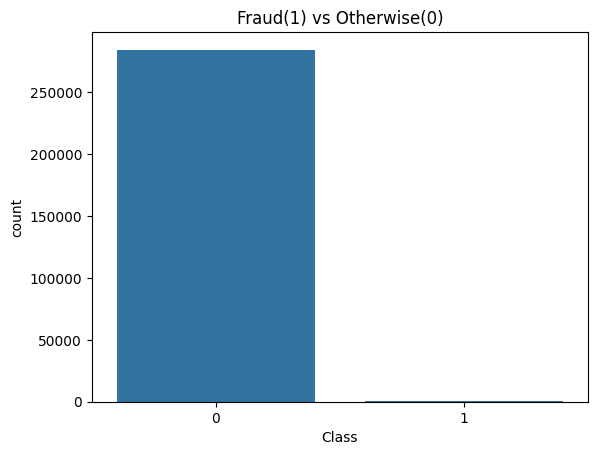

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df)
plt.title("Fraud(1) vs Otherwise(0)")
plt.show()

### 2.2 각 속성의 분포 시각화
---

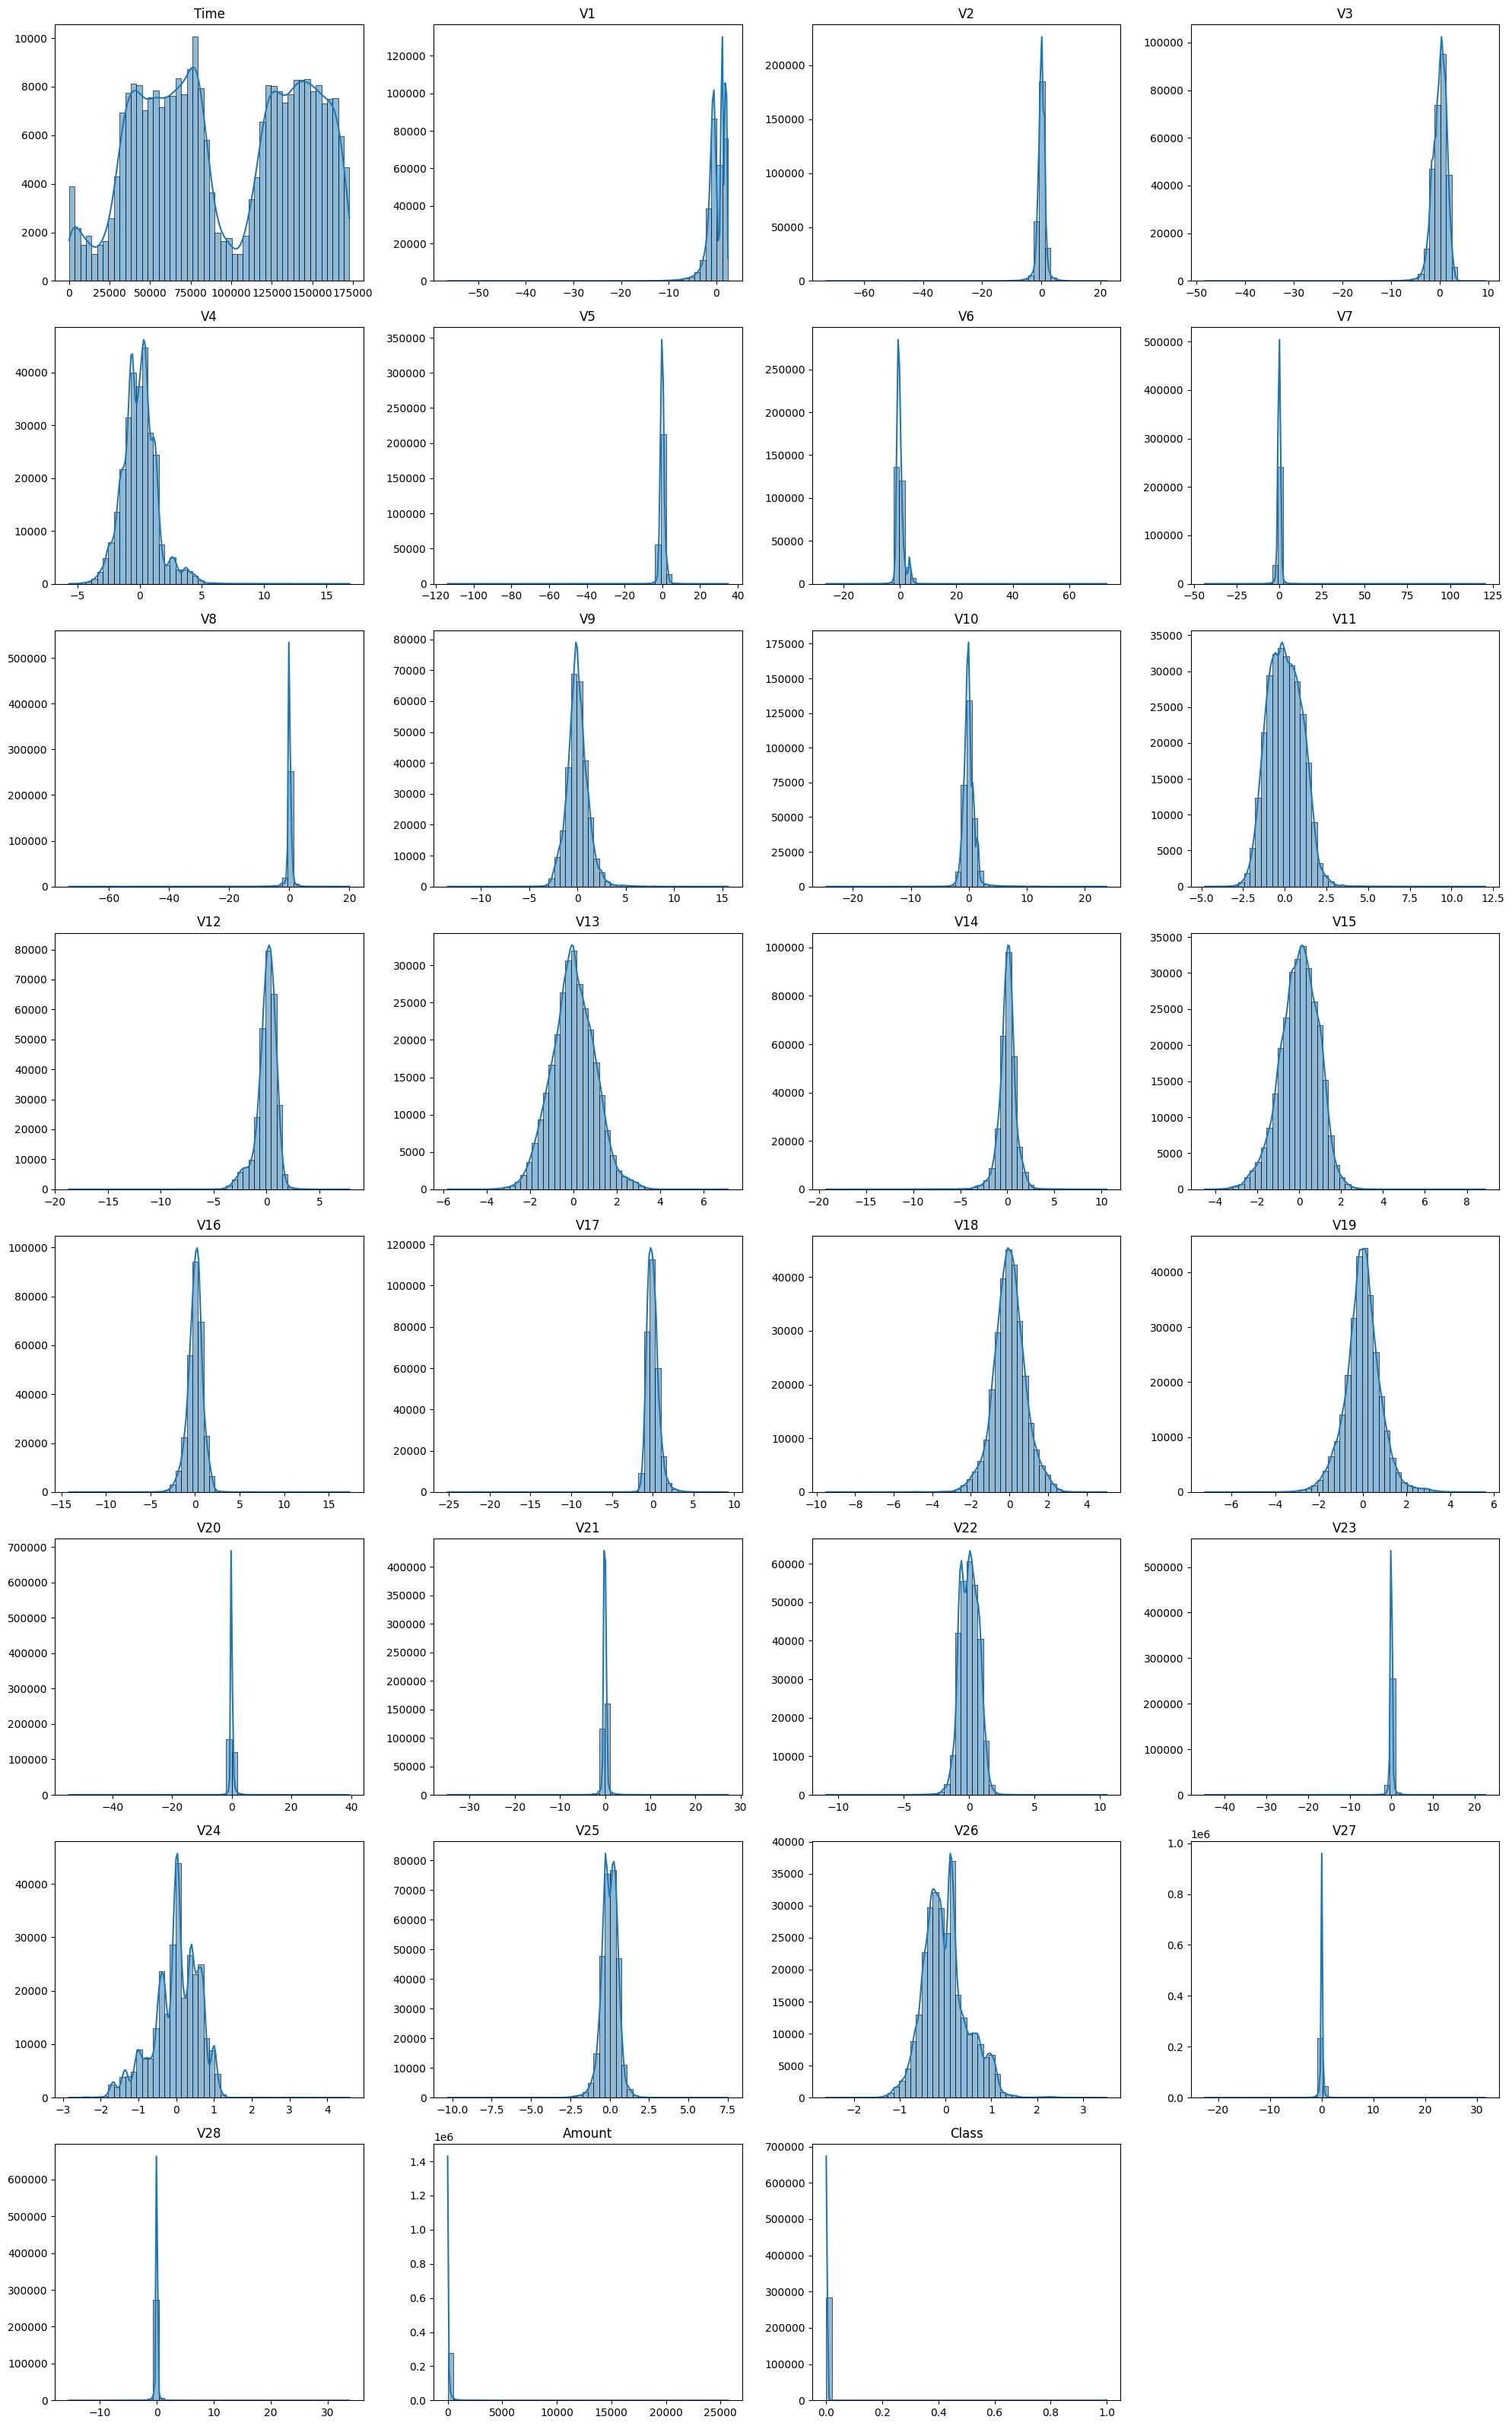

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

n_cols = 4
n_rows = -(-len(numeric_cols) // n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### 2.3 `Class`에 따른 `Amount` 분포 시각화
---

<Axes: xlabel='Class', ylabel='Amount'>

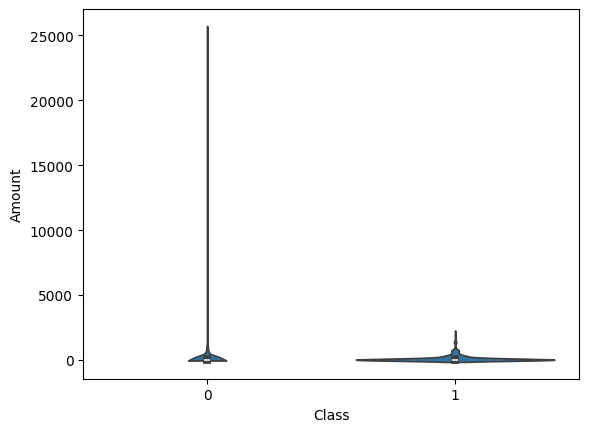

In [ ]:
sns.violinplot(x='Class', y='Amount', data=df)

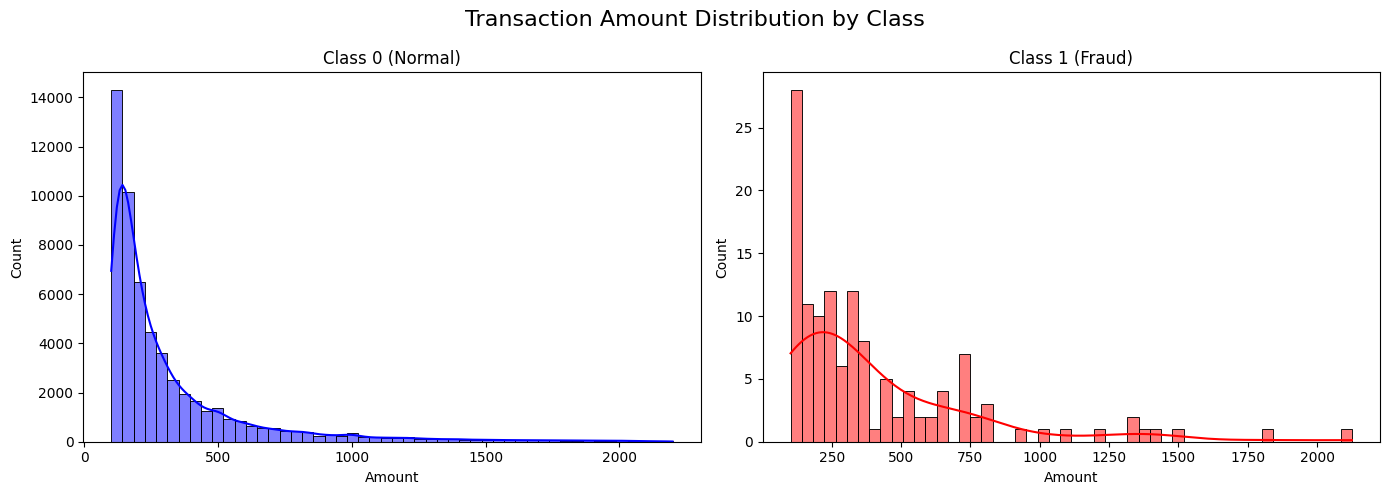

In [ ]:
# Amount가 1000미만인 값만 필터링
# df_temp = df[df['Amount'] < 2200]
df_temp = df[(df['Amount'] > 100) & (df['Amount'] < 2200)]

# Amount의 분포(히스토그램)
# plt.figure(figsize=(10, 6))
# sns.histplot(data=df_temp, x='Amount', bins=50, kde=True, hue='Class')

# 클래스별 데이터 분리
df_0 = df_temp[df_temp['Class'] == 0]
df_1 = df_temp[df_temp['Class'] == 1]

# 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class 0 (정상 거래)
sns.histplot(df_0['Amount'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Class 0 (Normal)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

# Class 1 (사기 거래)
sns.histplot(df_1['Amount'], bins=50, kde=True, ax=axes[1], color='red')
axes[1].set_title('Class 1 (Fraud)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')

plt.suptitle("Transaction Amount Distribution by Class", fontsize=16)
plt.tight_layout()
plt.show()

### 2.4 `클래스`와의 상관관계
---

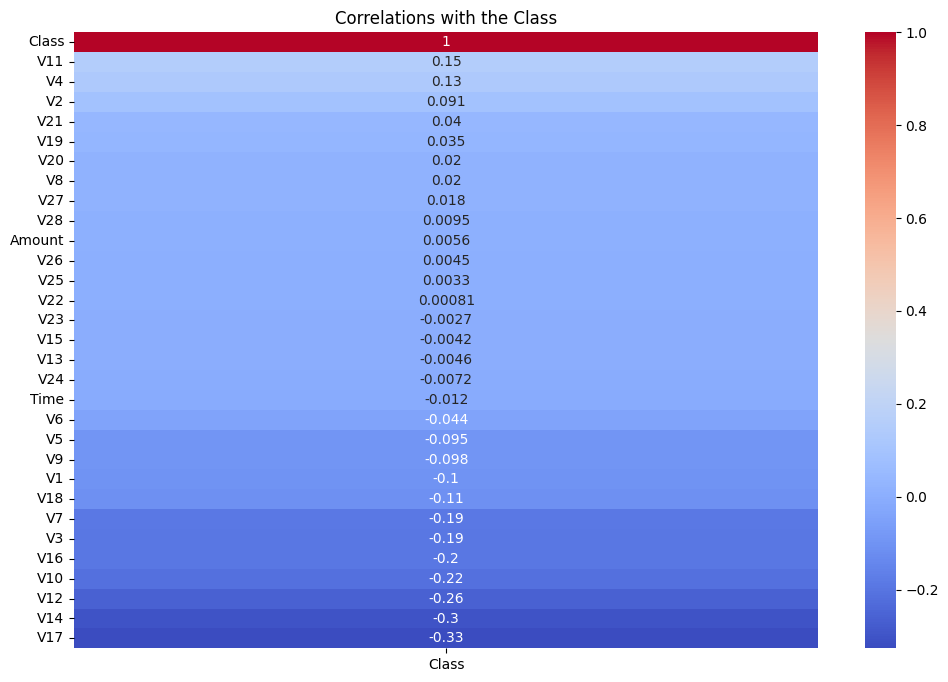

In [ ]:
# 상관관계 히트맵
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['Class']].sort_values('Class', ascending=False),
            annot=True, cmap='coolwarm')
plt.title('Correlations with the Class')
plt.show()

### 2.5 `Time` 구간별 발생 빈도 시각화
---

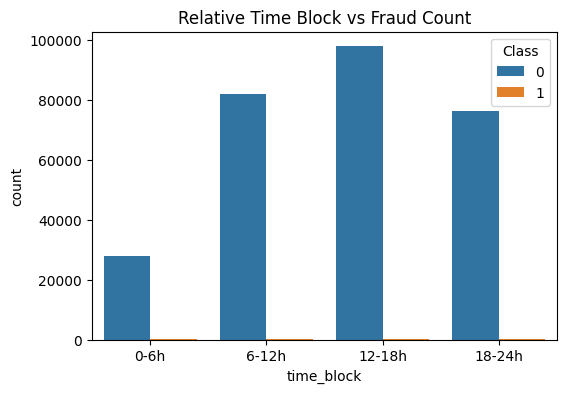

In [ ]:
# 거래 시간 기반 파생 변수 생성
# 하루 24시간으로 환산 (0~86400초 기준)
df['hour'] = (df['Time'] % 86400) // 3600
df.tail()

# 상대적 시간 구간 기준 분석
df['time_block'] = pd.cut(df['hour'],
                          bins=[-1, 6, 12, 18, 24],
                          labels=['0-6h', '6-12h', '12-18h', '18-24h'])

# 시간대별 사기 비율 시각화
plt.figure(figsize=(6, 4))
sns.countplot(x='time_block', hue='Class', data=df)#, hue=)
plt.title("Relative Time Block vs Fraud Count")
plt.show()

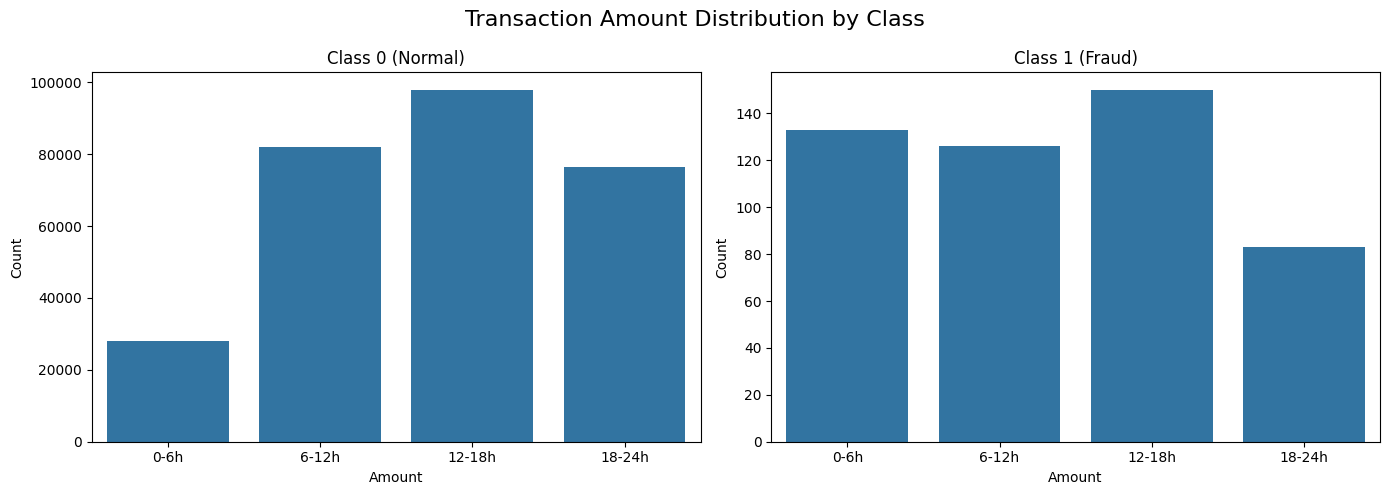

In [ ]:
# 클래스별 데이터 분리
df_0 = df[df['Class'] == 0]
df_1 = df[df['Class'] == 1]

# 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class 0 (정상 거래)
sns.countplot(x='time_block', data=df_0, ax=axes[0])
axes[0].set_title('Class 0 (Normal)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

# Class 1 (사기 거래)
sns.countplot(x='time_block', data=df_1, ax=axes[1])
axes[1].set_title('Class 1 (Fraud)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')

plt.suptitle("Transaction Amount Distribution by Class", fontsize=16)
plt.tight_layout()
plt.show()

## 3. 데이터 전처리
---
- 데이터 정제: 결측치 처리, 이상치 처리
- 데이터 변환

### 3.1 데이터 정제
---


#### 3.1.1 결측치 처리
---

In [ ]:
print(f'결측치 수:', df.isna().sum().sum())

결측치 수: 0


In [ ]:
df.dropna(inplace=True)

#### 3.1.2 이상치 처리
---

In [ ]:
# 1. z-score 계산 (Amount만 대상)
amount_mean = df['Amount'].mean()
amount_std = df['Amount'].std()
z = np.abs((df['Amount'] - amount_mean) / amount_std)

# 2. 이상치 여부 컬럼 생성
df['Amount_outlier'] = (z > 3).astype(int)

# 3. Class별 이상치 포함 여부 확인
class_outlier_summary = df.groupby('Class')['Amount_outlier'].value_counts().unstack().fillna(0).astype(int)
print("Class별 Amount 이상치 포함 여부:")
print(class_outlier_summary)

# 4. 이상치 제거
df_cleaned = df[df['Amount_outlier'] == 0].copy()

# 5. 결과 요약 출력
print(f"\n제거 전 데이터 크기: {df.shape}")
print(f"제거 후 데이터 크기: {df_cleaned.shape}")

Class별 Amount 이상치 포함 여부:
Amount_outlier       0     1
Class                       
0               280250  4065
1                  481    11

제거 전 데이터 크기: (284807, 34)
제거 후 데이터 크기: (280731, 34)


### 3.2 데이터 변환
---


#### 3.2.1 스케일링

In [ ]:
from sklearn.preprocessing import StandardScaler

# Amount 변수 스케일 조정
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# 기존 변수 제거
# df = df.drop(columns=['Time', 'Amount'])

#### 3.2.2 파생변수 생성

In [ ]:
# 거래 금액 기반 파생 변수 생성
# 거래 금액 로그 변환 (금액 분포 왜도 감소)
df['log_amount'] = np.log1p(df['Amount'])

# 금액 크기 구간화 (범주형 파생)
df['amount_bin'] = pd.cut(df['Amount'], bins=[-1, 10, 100, 1000, 10000, np.inf],
                          labels=['0~10', '10~100', '100~1K', '1K~10K', '10K+'])

# 평균 이상 거래 여부 (이진 플래그 변수)
df['is_large_transaction'] = (df['Amount'] > df['Amount'].mean()).astype(int)

In [ ]:
# 다변량 조건 파생 변수 생성
# 고금액 & 야간 거래 여부 (리스크 플래그)
df['high_risk_flag'] = ((df['Amount'] > 1000) & (df['hour'].between(0, 6))).astype(int)

# 사기 거래 비율 확인
print("High-risk 거래의 사기 발생 비율:")
print(df[df['high_risk_flag'] == 1]['Class'].mean())

High-risk 거래의 사기 발생 비율:
0.013071895424836602


#### 3.3.3 Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['time_block_encoded'] = le.fit_transform(df['time_block'])

print(df[['time_block', 'time_block_encoded']].drop_duplicates())

       time_block  time_block_encoded
0            0-6h                   0
14171       6-12h                   3
55133      12-18h                   1
102858     18-24h                   2


In [ ]:
# 원하는 순서대로 수동 매핑
bin_order = ['0~10', '10~100', '100~1K', '1K~10K', '10K+']
amount_bin_map = {bin_label: idx for idx, bin_label in enumerate(bin_order)}

# 매핑 적용
df['amount_bin_encoded'] = df['amount_bin'].map(amount_bin_map)

# 결과 확인
print(df[['amount_bin', 'amount_bin_encoded']].drop_duplicates())

      amount_bin amount_bin_encoded
0         100~1K                  2
1           0~10                  0
4         10~100                  1
51        1K~10K                  3
46841       10K+                  4


In [ ]:
df.drop(['time_block', 'amount_bin'], axis=1, inplace= True)

## 4. 머신러닝 모델 수행
---


### 4.1 RandomForestClassifier
---

#### 4.1.1 데이터 분할

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3, stratify=y, random_state=42)

#### 4.1.2 학습

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 모델 학습 (Random Forest)
model = RandomForestClassifier(n_estimators=100,
                               random_state=42,
                               class_weight='balanced')  # 불균형 대응
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

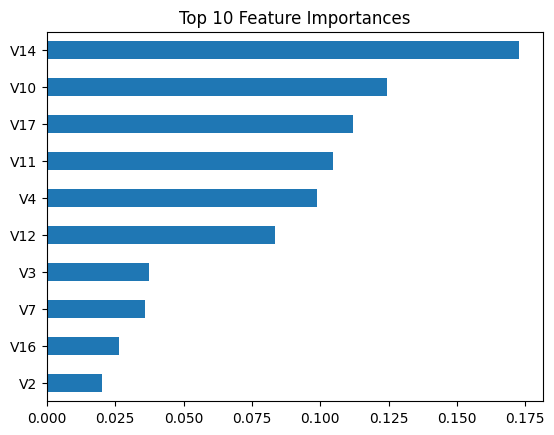

In [ ]:
# 중요 변수 시각화 (Feature Importance)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()

#### 4.1.3 평가


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# 정확도 지표
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC AUC Score: {roc_auc:.4f}')

[[85292     3]
 [   46   102]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.97      0.69      0.81       148

    accuracy                           1.00     85443
   macro avg       0.99      0.84      0.90     85443
weighted avg       1.00      1.00      1.00     85443

ROC AUC Score: 0.9342


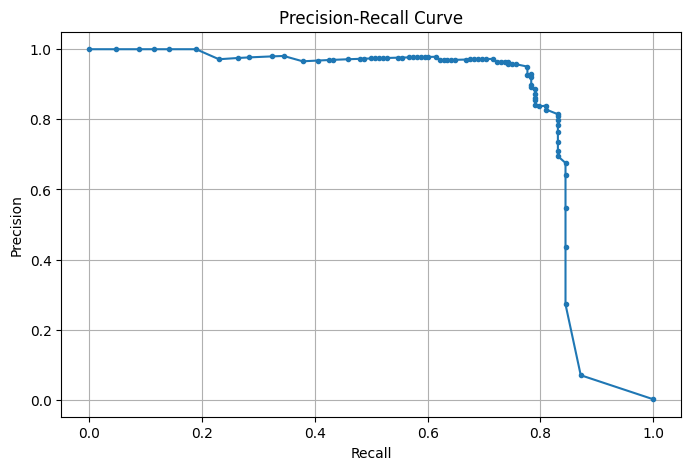

In [ ]:
# Precision-Recall Curve 시각화 (추천 지표)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

### 4.2 Feature Engineering

#### 4.2.1 불군형 데이터 처리(SMOTE)


In [ ]:
# 불균형 데이터 처리 – SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE

# 데이터 분할 (다시 필요 시 실행)
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# SMOTE 적용
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE 적용 후 클래스 분포:")
print(pd.Series(y_train_sm).value_counts())

SMOTE 적용 후 클래스 분포:
Class
0    199020
1    199020
Name: count, dtype: int64


#### 4.2.2 SMOTE 데이터로 모델 재학습

In [ ]:
# SMOTE 데이터로 모델 재학습
model_sm = RandomForestClassifier(n_estimators=100, random_state=42)
model_sm.fit(X_train_sm, y_train_sm)

# 평가
y_pred_sm = model_sm.predict(X_test)
y_proba_sm = model_sm.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_sm))
print("ROC AUC Score (SMOTE):", roc_auc_score(y_test, y_proba_sm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443

ROC AUC Score (SMOTE): 0.9508006790423699


---